# 04 - 财务指标采集

本 Notebook 完成以下任务：
1. 每日估值指标采集（PE/PB/PS/市值） → `stock_fundamental`
2. 季度财务指标采集（ROE/EPS 等） → `stock_fina_indicator`
3. 资金流向采集 → `stock_cashflow`

---

## 设计方案

### 两种财务数据的区别

| 数据 | 来源接口 | 更新频率 | 拉取方式 |
|------|---------|---------|----------|
| 每日估值 (PE/PB) | `daily_basic` | 每日 | 按日期拉全市场 |
| 季度财务 (ROE/EPS) | `fina_indicator` | 季度 | 按股票+报告期拉 |
| 资金流向 | `moneyflow` | 每日 | 按股票+日期拉 |

### 每日估值采集策略
`daily_basic` 接口按日期返回全市场数据（一次调用 ~5000 条），比逐股票拉取更高效。
增量更新逻辑：找出 `stock_fundamental` 表中缺失的交易日，按日补齐。

## 1. 每日估值指标（增量采集）

In [2]:
from invest_model.db import get_engine
from invest_model.sources.tushare_client import TushareClient
from invest_model.collectors.fundamental_collector import FundamentalCollector

engine = get_engine()
ts_client = TushareClient()
collector = FundamentalCollector(ts_client, engine)

# 增量采集（自动检测缺失日期）
n = collector.collect_daily_basic_incremental()
print(f"每日估值采集完成: {n} 条")

10:02:48 | INFO    | Tushare 客户端初始化完成
10:02:49 | INFO    | 每日估值缺失 1 天，开始增量采集
10:02:49 | INFO    | 每日估值采集完成: 1 天, 共 0 条


每日估值采集完成: 0 条


## 2. 季度财务指标

In [3]:
from invest_model.repositories.stock_pool_repo import StockPoolRepository

pool_repo = StockPoolRepository(engine)
stock_codes = pool_repo.get_pool_codes("core")
print(f"待采集: {stock_codes}")

n = collector.collect_fina_indicator(stock_codes)
print(f"季度财务采集完成: {n} 条")

待采集: ['000333.SZ', '000858.SZ', '300750.SZ', '600519.SH', '601318.SH']


10:03:13 | WARNING | Tushare 调用失败（第 1 次），2s 后重试: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
10:03:16 | INFO    | [季度财务] 进度: 5/5 (100%)
10:03:16 | INFO    | 季度财务采集完成: 5 只, 共 150 条


季度财务采集完成: 150 条


## 3. 资金流向（最近 30 个交易日示例）

In [4]:
from invest_model.repositories.calendar_repo import CalendarRepository

cal_repo = CalendarRepository(engine)
recent_dates = cal_repo.get_trade_dates("20260301", "20260406")
print(f"最近交易日: {len(recent_dates)} 天")

# 仅采集最近的交易日
n = collector.collect_cashflow(stock_codes, recent_dates[-5:])
print(f"资金流向采集完成: {n} 条")

最近交易日: 25 天


10:03:19 | INFO    | [资金流向] 进度: 5/5 (100%)
10:03:19 | INFO    | 资金流向采集完成: 5 只, 共 25 条, 失败 0 次


资金流向采集完成: 25 条


## 4. 数据验证

In [5]:
from invest_model.repositories.fundamental_repo import FundamentalRepository

repo = FundamentalRepository(engine)

# 查看贵州茅台估值
df = repo.get_daily_basic("600519.SH", "20260301", "20260406")
print("600519.SH 近期估值:")
print(df.tail(10).to_string(index=False))

print("\n")

# 查看季度财务
fina = repo.get_fina_indicator("600519.SH")
print(f"600519.SH 季度财务 ({len(fina)} 条):")
print(fina.tail(5).to_string(index=False))

600519.SH 近期估值:
     code trade_date  pe_ttm     pb  ps_ttm     total_mv      circ_mv          created_at
600519.SH   20260323 19.5861 7.7654  9.8741 1.763284e+08 1.763284e+08 2026-04-07 21:22:39
600519.SH   20260324 19.5758 7.7613  9.8689 1.762357e+08 1.762357e+08 2026-04-07 21:22:40
600519.SH   20260325 19.6167 7.7775  9.8895 1.766039e+08 1.766039e+08 2026-04-07 21:22:41
600519.SH   20260326 19.4903 7.7274  9.8258 1.754656e+08 1.754656e+08 2026-04-07 21:22:43
600519.SH   20260327 19.6967 7.8092  9.9298 1.773240e+08 1.773240e+08 2026-04-07 21:22:44
600519.SH   20260330 19.7520 7.8312  9.9578 1.778224e+08 1.778224e+08 2026-04-07 21:22:46
600519.SH   20260331 20.1693 7.9966 10.1681 1.815792e+08 1.815792e+08 2026-04-07 21:22:46
600519.SH   20260401 20.3006 8.0487 10.2343 1.827613e+08 1.827613e+08 2026-04-07 21:22:48
600519.SH   20260402 20.3068 8.0511 10.2374 1.828164e+08 1.828164e+08 2026-04-07 21:22:49
600519.SH   20260403 20.3084 8.0518 10.2383 1.828315e+08 1.828315e+08 2026-04-07 21:

## 5. 估值走势（PE / PB）

基于 `stock_fundamental` 中已入库数据绘图。

/tmp/ipykernel_641407/2223856688.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ax2.plot(x, vplot["pb"].fillna(method="ffill"), color="#dc2626", label="PB", linewidth=1.0, alpha=0.85)


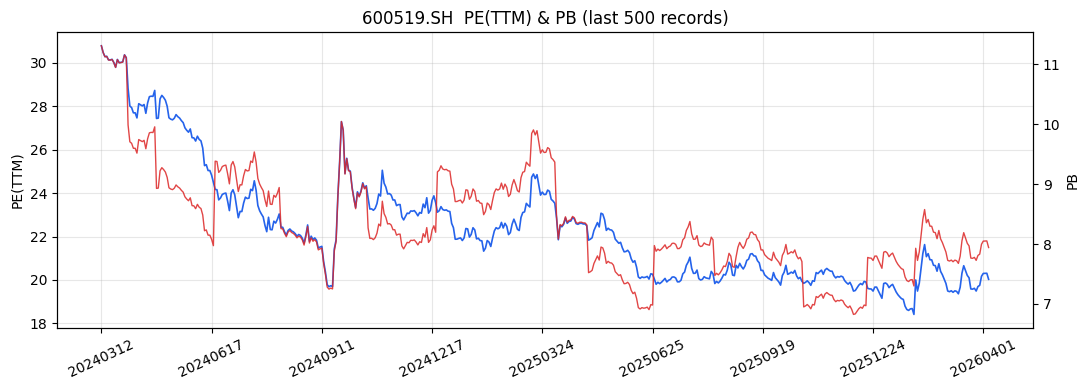

In [6]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

fr = FundamentalRepository(engine)
vplot = fr.get_daily_basic("600519.SH", "20200101", "20991231")
if vplot.empty or "pe_ttm" not in vplot.columns:
    print("No valuation data, skip chart")
else:
    vplot = vplot.dropna(subset=["pe_ttm"]).tail(500).reset_index(drop=True)
    x = range(len(vplot))
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(x, vplot["pe_ttm"], color="#2563eb", label="PE(TTM)", linewidth=1.2)
    ax1.set_ylabel("PE(TTM)")
    ax1.grid(True, alpha=0.3)
    if "pb" in vplot.columns:
        ax2 = ax1.twinx()
        ax2.plot(x, vplot["pb"].fillna(method="ffill"), color="#dc2626", label="PB", linewidth=1.0, alpha=0.85)
        ax2.set_ylabel("PB")
    step = max(1, len(vplot) // 8)
    ax1.set_xticks(list(x)[::step])
    ax1.set_xticklabels(vplot["trade_date"].astype(str).iloc[::step], rotation=25)
    ax1.set_title("600519.SH  PE(TTM) & PB (last 500 records)")
    plt.tight_layout()
    plt.show()

## 完成

财务数据采集完毕，继续 `05_etf_data.ipynb` 采集 ETF 数据。